In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv


# Problem Statement



Academic performance is influenced by multiple factors such as study habits, attendance, sleep patterns, internet usage, assignment completion, and previous academic results. Identifying how these factors contribute to a student's final exam score can help educators and students make informed decisions to improve learning outcomes.

The objective of this project is to develop a machine learning regression model that predicts a student's exam score based on behavioral and academic factors. In addition to prediction, the project aims to analyze the relative importance of different factors and understand which aspects of student behavior have the greatest impact on academic performance.**

# Objectives of This Project

**Explore and analyze the relationships between student-related factors and exam scores.
Build and compare multiple regression models for exam score prediction.
Evaluate model performance using appropriate regression metrics.
Identify the most influential factors affecting student academic performance.
Provide insights that may help improve educational outcomes.**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv')
df.head(7)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed


In [4]:
df.shape

(10000, 8)

In [5]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [7]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

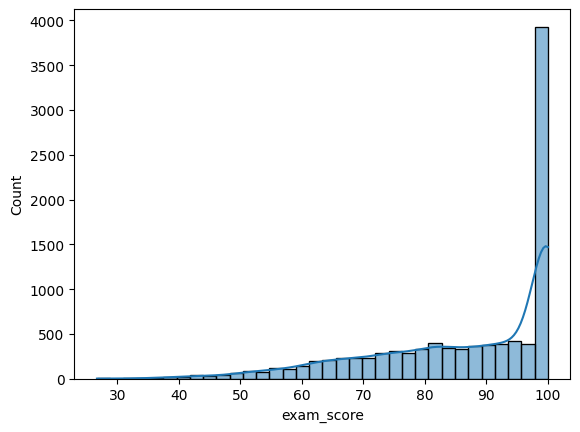

In [8]:
sns.histplot(df['exam_score'], kde=True)
plt.savefig('exam_score_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

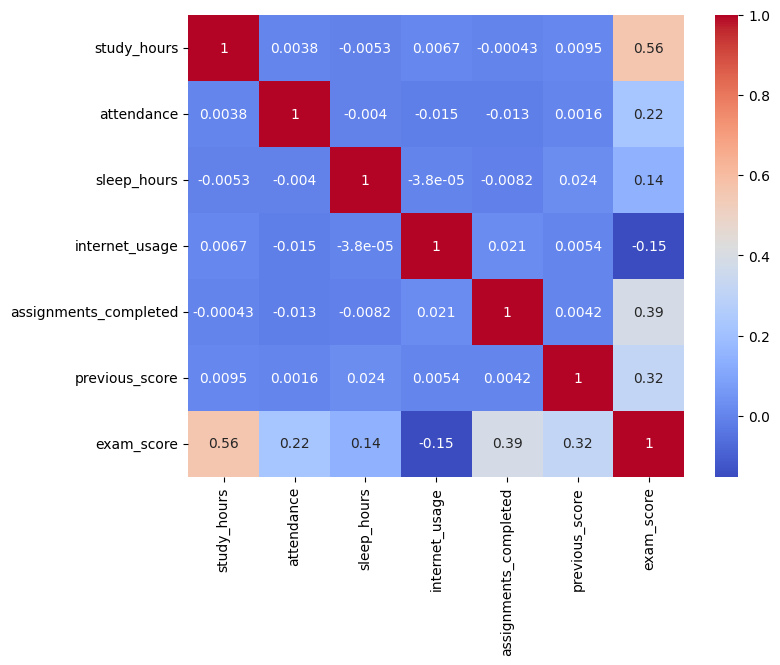

In [9]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig('heatmap_performance.png', dpi = 300, bbox_inches = 'tight')
plt.show()

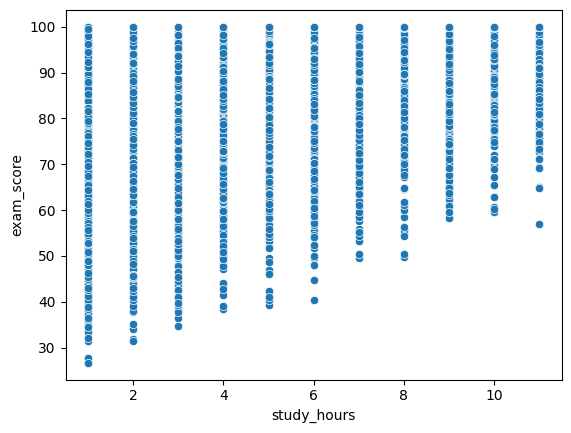

In [10]:
sns.scatterplot(
    x='study_hours',
    y='exam_score',
    data=df
)
plt.show()

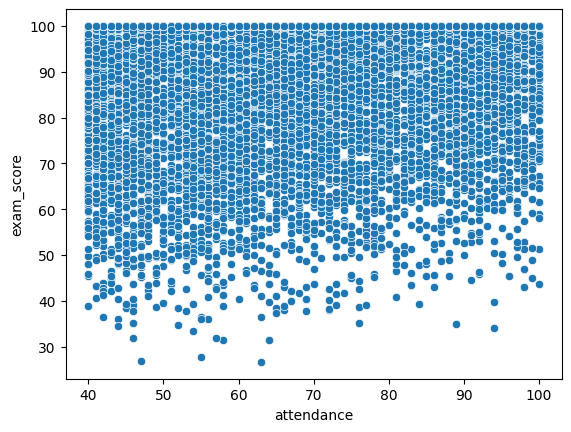

In [11]:
sns.scatterplot(
    x='attendance',
    y='exam_score',
    data=df
)
plt.show()

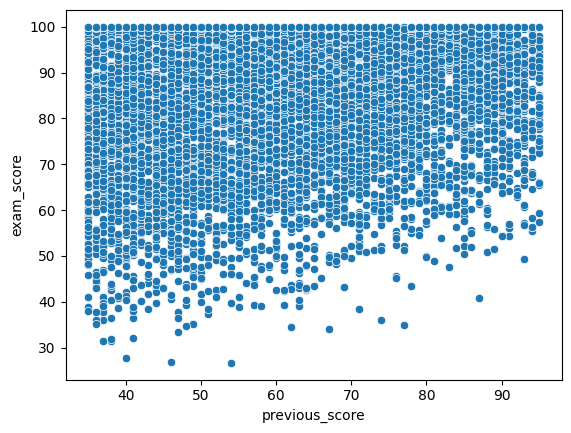

In [12]:
sns.scatterplot(
    x='previous_score',
    y='exam_score',
    data=df
)
plt.show()

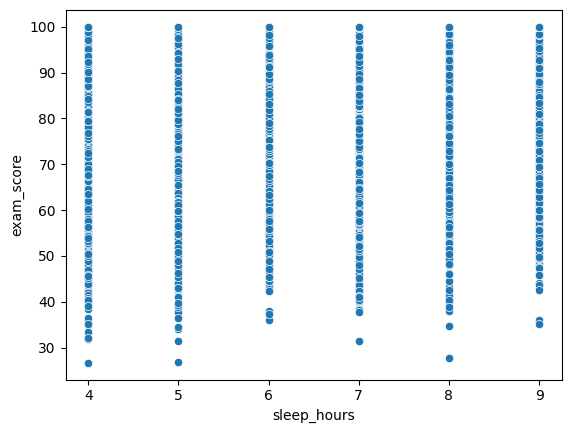

In [13]:
sns.scatterplot(
    x='sleep_hours',
    y='exam_score',
    data=df
)
plt.show()

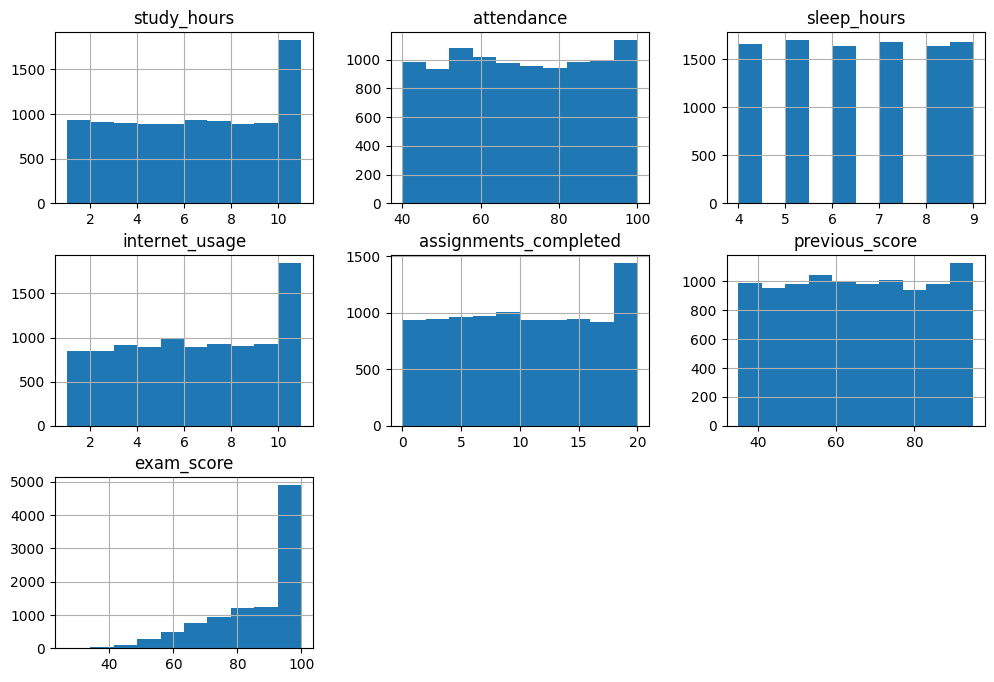

In [14]:
df.hist(figsize=(12,8))
plt.savefig('performance_distribution.png',dpi= 300, bbox_inches = 'tight')
plt.show()

In [15]:
corr_target = (
    df.select_dtypes(include=['number'])
      .corr()[['exam_score']]
      .sort_values(by='exam_score', ascending=False)
)

corr_target

,exam_score
exam_score,1.000000
study_hours,0.562528
assignments_completed,0.387609
previous_score,0.318805
attendance,0.223367
sleep_hours,0.144675
internet_usage,-0.151896


In [16]:
df.describe().T
df.skew(numeric_only=True)

study_hours             -0.007221
attendance               0.017849
sleep_hours              0.005082
internet_usage          -0.013482
assignments_completed    0.017779
previous_score           0.000422
exam_score              -1.008607
dtype: float64

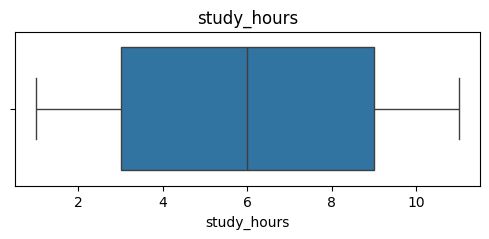

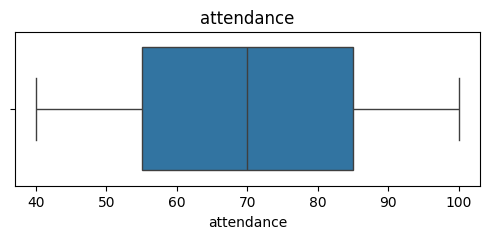

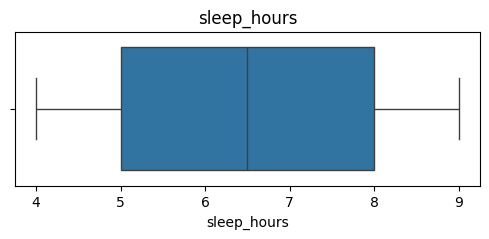

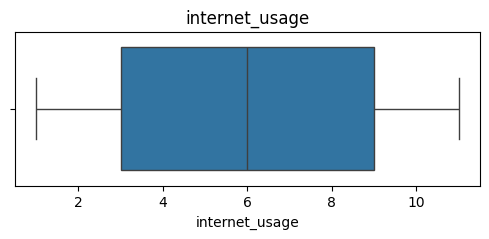

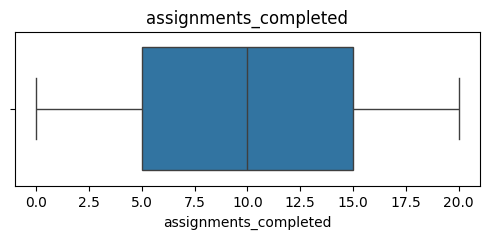

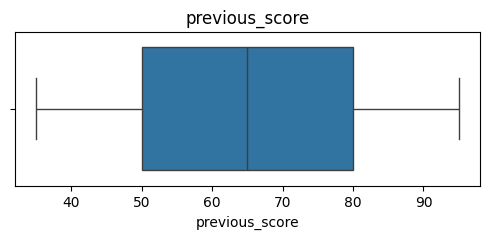

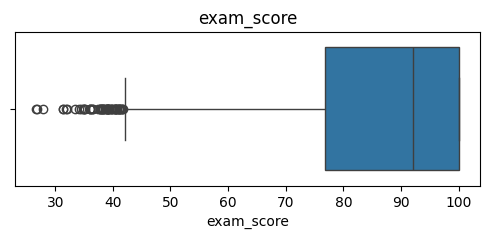

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### EDA Insights

The dataset contains 10,000 student records and is well-suited for exam score prediction. The target variable, **exam_score**, shows a moderately left-skewed distribution, indicating that most students achieved relatively high scores.

Correlation analysis revealed that **study_hours** has the strongest positive relationship with exam scores (r = 0.563), making it the most influential feature. **Assignments_completed** (r = 0.388) and **previous_score** (r = 0.319) also contribute positively to student performance. **Attendance** and **sleep_hours** show weaker positive relationships, while **internet_usage** has a weak negative correlation (r = -0.152) with exam scores.

Scatter plot analysis supports these findings, showing that students who study more and complete more assignments generally achieve higher exam scores. Outlier analysis identified a small number of outliers only in the target variable (**exam_score**), while the remaining features appear well-distributed without significant anomalies.


# DATA CLEANING

In [18]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop('placement_status', axis=1)

**Although a small number of outliers were observed in the target variable, they were retained because they may represent genuine student performance rather than data entry errors.**

**No missing values found.
No duplicate records found.
Irrelevant categorical column (placement_status) removed.
Outliers in exam_score retained because they represent realistic observations.
Numerical features standardized before model trainin**

# DATA PREPROCESSING

In [21]:
# Imports

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [22]:
# Features and Target

X = df.drop(['exam_score'], axis=1)
y = df['exam_score']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Standard Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL TRAINING

In [24]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)

In [25]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)

In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)

In [27]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)

# Model Evaluation 

In [28]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'R² Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results = results.sort_values(
    by='R² Score',
    ascending=False
)

results

,Model,R² Score
3,XGBoost,0.729227
2,Random Forest,0.712521
0,Linear Regression,0.663446
1,Decision Tree,0.376354


In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.728239861831666
RMSE: 7.887158155353002


In [30]:
print("Train R²:", xgb.score(X_train, y_train))
print("Test R²:", xgb.score(X_test, y_test))

Train R²: 0.7995386455162978
Test R²: 0.7292265089879304


# Model Evaluation Summary

1. Best Model: XGBoost (R² = 0.729)
2. Second Best: Random Fores1. t (R² = 0.713)
3. Most Important Feature: Study Hours (0.450)
4. Least Important Feature: Internet Usage (0.062)

# Feature Importance Analysis

In [31]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,study_hours,0.449655
4,assignments_completed,0.213302
5,previous_score,0.128059
1,attendance,0.074691
2,sleep_hours,0.071851
3,internet_usage,0.062441


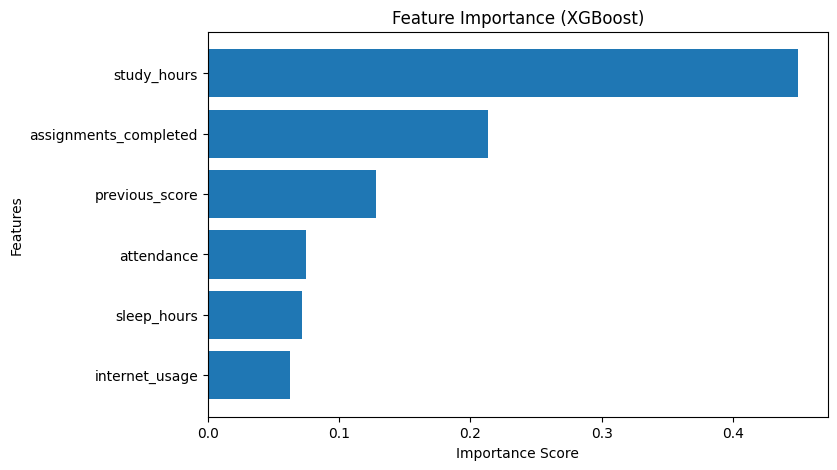

In [32]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (XGBoost)")
plt.savefig('feature_importance.png',dpi= 300, bbox_inches = 'tight')
plt.show()

# Project Report

Feature importance analysis using the XGBoost model revealed that **study_hours** was the most influential predictor of exam performance, contributing approximately 45% of the total importance score. **Assignments_completed** emerged as the second most important factor, followed by **previous_score**. Attendance, sleep hours, and internet usage showed comparatively lower importance. These findings suggest that consistent study habits and active engagement with coursework have a greater impact on academic performance than lifestyle-related factors in this dataset.


# Report Conclusion

**Students who dedicate more time to studying and consistently complete assignments tend to achieve better examination results. While previous academic performance contributes to prediction, current study behavior appears to be a stronger indicator of future exam success.Among all evaluated models, XGBoost achieved the highest predictive performance with an R² score of 0.729. Feature importance analysis revealed that study hours and assignment completion were the most influential factors affecting student exam performance.**